-------------

> Bueno pues vamos a volver a empezar con otro prototipo de mejora de Daowa-Maad
> PD: Todo el código anterior está en mi GitHub, en el tag v3.0 rc-1 

-------------

In [1]:
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv()

token = os.getenv("hf_token")
login(token)

c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                           $
#  Importación de librerías                 $
#                                           $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

import timm
import datetime
import cv2
import numpy as np
import torch
import pandas as pd
from typing import Any
from tqdm import tqdm
from torch import nn
from PIL import Image
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode, functional

--------------------------------

> Para esta prueba usaremos albumentations y darle más peso a la clase borde, para observar sus resultados

-------------------------------

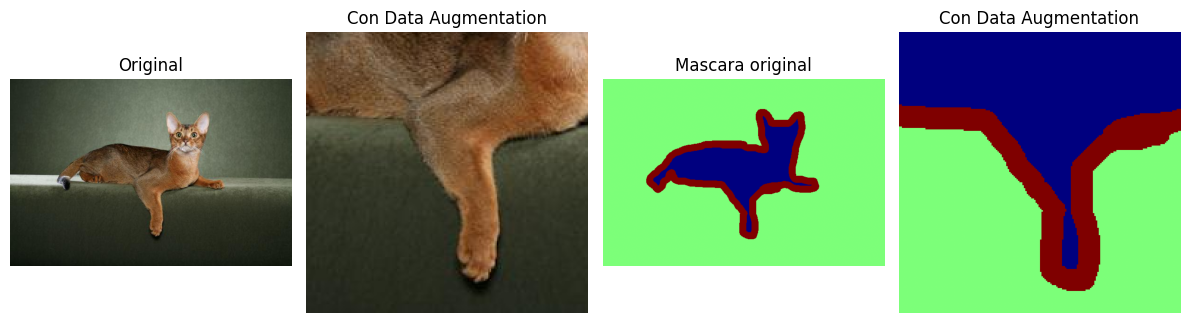

In [3]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                        $ 
# Muestra de Data Augmentation (Mismos parámetros para el entrenamiento) $
#                                                                        $  
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

import albumentations as A
import cv2
import matplotlib.pyplot as plt

transform = A.Compose([
    A.RandomCrop(height=192, width=192),
    A.HorizontalFlip(p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(0.05, 0.15),
        hole_width_range=(0.05, 0.15),
        p=0.3
    ),
])

img = cv2.imread('data/image/images/Abyssinian_1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mascara = cv2.imread('data/image/masks/Abyssinian_1.png', cv2.IMREAD_GRAYSCALE)

resultado = transform(image=img, mask = mascara)
trans_img = resultado['image']
trans_mascara = resultado['mask']

fig, ax = plt.subplots(1, 4, figsize=(12, 5))
ax[0].imshow(img)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(trans_img)
ax[1].set_title('Con Data Augmentation')
ax[1].axis('off')

ax[2].imshow(mascara, cmap='jet', vmin=0, vmax=2)
ax[2].set_title('Mascara original')
ax[2].axis('off')

ax[3].imshow(trans_mascara, cmap='jet', vmin=0, vmax=2)
ax[3].set_title('Con Data Augmentation')
ax[3].axis('off')


plt.tight_layout()
plt.show()

In [4]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                             $
# Generación de parámetros para ajustar el learning rate el encoder y decoder $
#                                                                             $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
from utils.models.daowa_maadV3Prueba import Daowa_maadPrueba

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

modelo = Daowa_maadPrueba(num_clases=3)
modelo = modelo.to(device)
#summary(modelo)

# 1. Parámetros del encoder (ConvNeXtV2 preentrenado)
encoder_params = list(modelo.encoder.parameters())

# 2. Todo lo que NO sea encoder (attention gates, upsampling, head, etc.)
encoder_ids = set(id(p) for p in encoder_params)
decoder_params = [p for p in modelo.parameters() if id(p) not in encoder_ids]

# 3. Verificar que no se perdió ningún parámetro
print(f"Encoder: {len(encoder_params)} tensores")
print(f"Decoder: {len(decoder_params)} tensores")
print(f"Total modelo: {sum(p.numel() for p in modelo.parameters()):,} parámetros")

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 1e-5, 'weight_decay': 1e-4},   # Pre-trained → LR bajo
    {'params': decoder_params, 'lr': 1e-4, 'weight_decay': 1e-4},    # Tu decoder → LR normal
])

Encoder: 196 tensores
Decoder: 65 tensores
Total modelo: 37,165,257 parámetros


In [5]:
from utils.losses.dice_loss import GeneralizedDiceLossFN
from utils.train.trainer import train_model
from utils.models.datasets import get_dataloaders
from torchinfo import summary

losses = [
    torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 0.5, 2.0]).to(device)),
    GeneralizedDiceLossFN(target_classes=3, epsilon=1e-6)
]

dataloaders = get_dataloaders(batch_size=16, shuffle=False, num_workers=4)

train_model(
    modelo = modelo,
    loss_fn = losses,
    optimizador = optimizer,
    dataloaders = dataloaders,
    device_calc = device,
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1),
    epochs = 10
)

Iniciando entrenamiento


Entrenando el modelo:  10%|█         | 1/10 [00:57<08:33, 57.08s/it]

--> Nuevo mejor modelo con acc: 0.76
Epoch 1: Train Loss = 0.5268; Precision = 80.9965; Validation loss = 0.3061, Precisión = 90.3556%, IoU Global = 0.7567, IoU Clase [Mascota, Fondo, Borde] = [0.8361884355545044, 0.910537838935852, 0.5234707593917847]


Entrenando el modelo:  20%|██        | 2/10 [01:50<07:17, 54.69s/it]

--> Nuevo mejor modelo con acc: 0.78
Epoch 2: Train Loss = 0.3028; Precision = 89.8142; Validation loss = 0.2727, Precisión = 91.7361%, IoU Global = 0.7815, IoU Clase [Mascota, Fondo, Borde] = [0.8614681959152222, 0.9229187965393066, 0.5602566599845886]


...

Entrenando el modelo:  90%|█████████ | 9/10 [08:05<00:54, 54.15s/it]

--> Nuevo mejor modelo con acc: 0.79
Epoch 9: Train Loss = 0.1476; Precision = 95.7054; Validation loss = 0.3166, Precisión = 92.8340%, IoU Global = 0.7946, IoU Clase [Mascota, Fondo, Borde] = [0.87205570936203, 0.9371821284294128, 0.5747093558311462]


Entrenando el modelo: 100%|██████████| 10/10 [08:58<00:00, 53.88s/it]

Epoch 10: Train Loss = 0.1404; Precision = 95.9274; Validation loss = 0.3548, Precisión = 92.3929%, IoU Global = 0.7829, IoU Clase [Mascota, Fondo, Borde] = [0.8705049157142639, 0.9307128190994263, 0.5474364161491394]


'Entrenamiento completado'

c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Segoe UI.
  fig.canvas.print_figure(byte

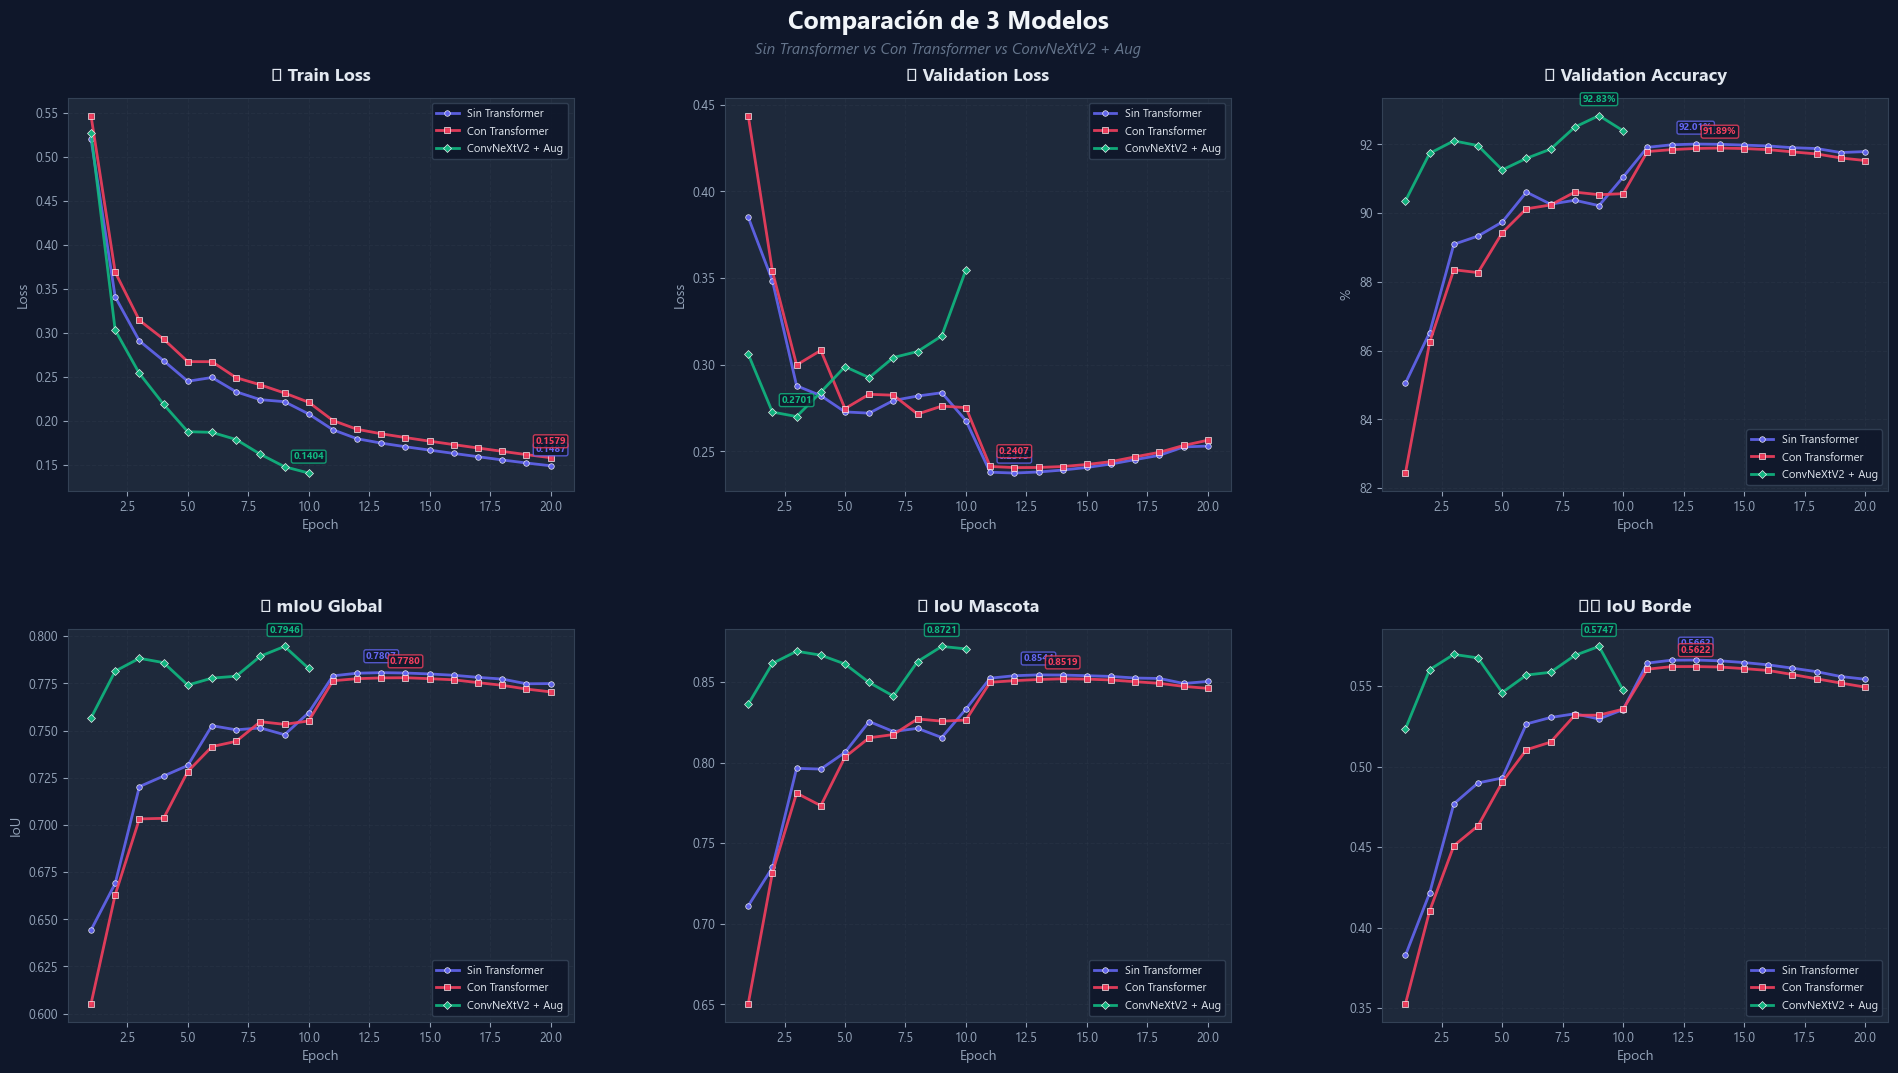


  📊 RESUMEN COMPARATIVO — Mejor epoch de cada modelo
Métrica                      Sin Transformer   Con Transformer  ConvNeXtV2 + Aug
--------------------------------------------------------------------------------
  Mejor epoch                             13                14                 9
  Val Loss                            0.2382            0.2413            0.3166
  Val Accuracy                        92.01%            91.89%            92.83%
  mIoU Global                         0.7807            0.7780            0.7946
  IoU Mascota                         0.8544            0.8519            0.8721
  IoU Fondo                           0.9215            0.9202            0.9372
  IoU Borde ⚠️                        0.5662            0.5619            0.5747


In [6]:
from utils.visualization.compare import comparar_entrenamientos

comparar_entrenamientos(
    ('logs/training_history2026-03-04.csv', 'Sin Transformer'),
    ('logs/training_history2026-03-04_2.csv', 'Con Transformer'),
    ('logs/training_history2026-03-10.csv', 'ConvNeXtV2 + Aug'),
)